In [22]:
import albumentations as A
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

from auxiliary.model_utils import *
from auxiliary.cnn_class import CNN
from auxiliary.pokemon_dataset import PokemonDataset
from auxiliary.numpy_dataset import NumpyDataset

In [ ]:
DATA_DIR = Path.home() / "Library" / "CloudStorage" / "GoogleDrive-jesstwentworth@gmail.com" / "My Drive" / "Machine Learning Group Project" # Google Drive path
# DATA_DIR    = "Pokemon"
IMG_SIZE    = (64, 64)
BATCH_SIZE  = 32
EPOCHS      = 50
LR          = 1e-3
N_FOLDS     = 5
RANDOM_SEED = 1996
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
 
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print(f"Using device: {DEVICE}")


Using device: cpu


In [3]:
train_transform = A.Compose([
    A.Resize(64, 64),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(64, 64),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

# Run with cleaned images (5 aug)

In [ ]:
# 1. Load the .npy files
# x_train_5aug = np.load('./Pokemon/X_train_5aug.npy')
# y_train_5aug = np.load('./Pokemon/y_train_5aug.npy')

# x_val_5aug = np.load('./Pokemon/X_val_5aug.npy')
# y_val_5aug = np.load('./Pokemon/y_val_5aug.npy')

# x_test_5aug = np.load('./Pokemon/X_test_5aug.npy')
# y_test_5aug = np.load('./Pokemon/y_test_5aug.npy')

# Google Drive path
x_train_5aug = np.load(DATA_DIR / "X_train_5aug.npy") 
y_train_5aug = np.load(DATA_DIR / "y_train_5aug.npy")

x_val_5aug = np.load(DATA_DIR / "X_val_5aug.npy")
y_val_5aug = np.load(DATA_DIR / "y_val_5aug.npy")

x_test_5aug = np.load(DATA_DIR / "X_test_5aug.npy")
y_test_5aug = np.load(DATA_DIR / "y_test_5aug.npy")

le = LabelEncoder()
y_train_idx_5aug = le.fit_transform(y_train_5aug)  
y_val_idx_5aug   = le.transform(y_val_5aug)        
y_test_idx_5aug  = le.transform(y_test_5aug)

# Save the class names for later plotting
class_names = le.classes_
print(f"Detected {len(class_names)} classes: {class_names}")

Detected 151 classes: ['abra' 'aerodactyl' 'alakazam' 'arbok' 'arcanine' 'articuno' 'beedrill'
 'bellsprout' 'blastoise' 'bulbasaur' 'butterfree' 'caterpie' 'chansey'
 'charizard' 'charmander' 'charmeleon' 'clefable' 'clefairy' 'cloyster'
 'cubone' 'dewgong' 'diglett' 'ditto' 'dodrio' 'doduo' 'dragonair'
 'dragonite' 'dratini' 'drowzee' 'dugtrio' 'eevee' 'ekans' 'electabuzz'
 'electrode' 'exeggcute' 'exeggutor' "farfetch'd" 'fearow' 'flareon'
 'gastly' 'gengar' 'geodude' 'gloom' 'golbat' 'goldeen' 'golduck' 'golem'
 'graveler' 'grimer' 'growlithe' 'gyarados' 'haunter' 'hitmonchan'
 'hitmonlee' 'horsea' 'hypno' 'ivysaur' 'jigglypuff' 'jolteon' 'jynx'
 'kabuto' 'kabutops' 'kadabra' 'kakuna' 'kangaskhan' 'kingler' 'koffing'
 'krabby' 'lapras' 'lickitung' 'machamp' 'machoke' 'machop' 'magikarp'
 'magmar' 'magnemite' 'magneton' 'mankey' 'marowak' 'meowth' 'metapod'
 'mew' 'mewtwo' 'moltres' 'mr mime' 'muk' 'nidoking' 'nidoqueen'
 'nidoran♀' 'nidoran♂' 'nidorina' 'nidorino' 'ninetales' 'oddi

In [5]:
train_loader_5aug = DataLoader(NumpyDataset(x_train_5aug, y_train_idx_5aug, transform=train_transform), 
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader_5aug   = DataLoader(NumpyDataset(x_val_5aug, y_val_idx_5aug, transform=val_transform), 
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader_5aug  = DataLoader(NumpyDataset(x_test_5aug, y_test_idx_5aug, transform=val_transform), 
                          batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# Initialize Model
model_5aug = CNN(num_classes=len(le.classes_)).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model_5aug.parameters(), lr=1e-4, weight_decay=0.01)

# Dictionary to store history for plotting
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    model_5aug.train()
    train_loss, train_correct = 0, 0
    
    for images, labels in train_loader_5aug:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model_5aug(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
    
    # Validation
    model_5aug.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader_5aug:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model_5aug(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            
    # Calculate averages
    metrics = {
        "train_loss": train_loss / len(x_train_5aug),
        "train_acc":  train_correct / len(x_train_5aug),
        "val_loss":   val_loss / len(x_val_5aug),
        "val_acc":    val_correct / len(x_val_5aug)
    }
    
    for key in history: history[key].append(metrics[key])
    
    print(f"Epoch {epoch:02d}/{EPOCHS} | Train Loss: {metrics['train_loss']:.4f} Acc: {metrics['train_acc']:.4f} | "
          f"Val Loss: {metrics['val_loss']:.4f} Acc: {metrics['val_acc']:.4f}")

# RUNTIME: 77 min and 20sec

Detected flattened size: 8192
Epoch 01/50 | Train Loss: 4.6647 Acc: 0.0447 | Val Loss: 3.8391 Acc: 0.1573
Epoch 02/50 | Train Loss: 3.7812 Acc: 0.1559 | Val Loss: 3.1694 Acc: 0.2823
Epoch 03/50 | Train Loss: 3.2456 Acc: 0.2491 | Val Loss: 2.8543 Acc: 0.3444
Epoch 04/50 | Train Loss: 2.8355 Acc: 0.3236 | Val Loss: 2.6301 Acc: 0.3816
Epoch 05/50 | Train Loss: 2.5214 Acc: 0.3812 | Val Loss: 2.4620 Acc: 0.4073
Epoch 06/50 | Train Loss: 2.2699 Acc: 0.4360 | Val Loss: 2.3636 Acc: 0.4512
Epoch 07/50 | Train Loss: 2.0494 Acc: 0.4844 | Val Loss: 2.3008 Acc: 0.4743
Epoch 08/50 | Train Loss: 1.8741 Acc: 0.5210 | Val Loss: 2.2297 Acc: 0.4801
Epoch 09/50 | Train Loss: 1.7327 Acc: 0.5568 | Val Loss: 2.2135 Acc: 0.5116
Epoch 10/50 | Train Loss: 1.6078 Acc: 0.5808 | Val Loss: 2.1804 Acc: 0.5199
Epoch 11/50 | Train Loss: 1.4803 Acc: 0.6080 | Val Loss: 2.2055 Acc: 0.5149
Epoch 12/50 | Train Loss: 1.3657 Acc: 0.6383 | Val Loss: 2.1519 Acc: 0.5248
Epoch 13/50 | Train Loss: 1.2746 Acc: 0.6593 | Val Loss: 2

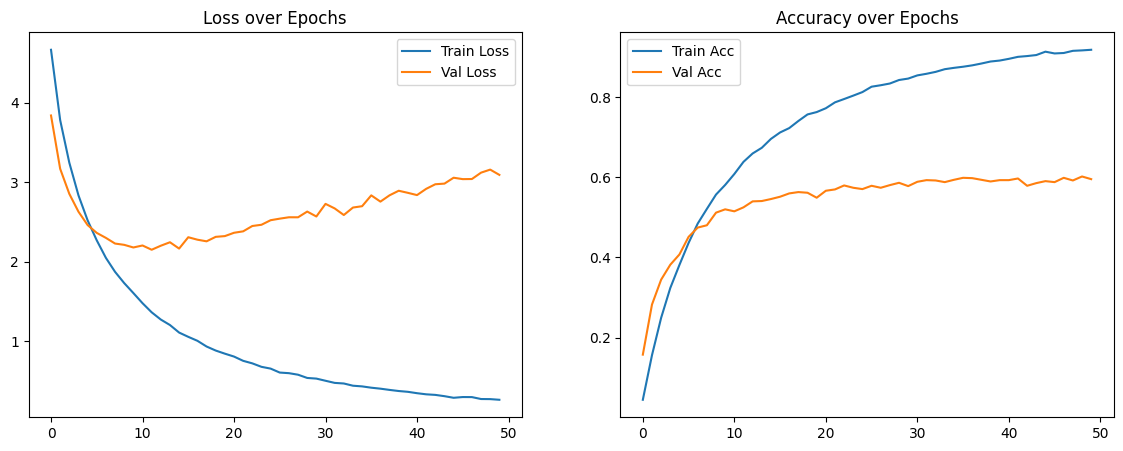

In [7]:
# 1. Plot Training/Validation Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history["train_loss"], label="Train Loss")
ax1.plot(history["val_loss"], label="Val Loss")
ax1.set_title("Loss over Epochs")
ax1.legend()

ax2.plot(history["train_acc"], label="Train Acc")
ax2.plot(history["val_acc"], label="Val Acc")
ax2.set_title("Accuracy over Epochs")
ax2.legend()

plt.show()

In [28]:
# 2. Final Evaluation on Test Set
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import torch.nn.functional as F

model_5aug.eval()
all_preds = []
all_labels = []
all_probs = [] # Needed for ROC-AUC

with torch.no_grad():
    for images, labels in test_loader_5aug:
        images = images.to(DEVICE)
        outputs = model_5aug(images)
        
        # Get probabilities using Softmax
        probs = F.softmax(outputs, dim=1)
        
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

# 1. Precision, Recall, and F1-score
# These are all included in the classification_report
print("--- Detailed Classification Report ---")
# target_names uses the labels from your LabelEncoder
# report = classification_report(all_labels, all_preds, target_names=le.classes_)
# print(report)
print(classification_report(all_labels, all_preds, target_names=le.classes_, zero_division=0))

report = classification_report(
    all_labels,
    all_preds,
    target_names=le.classes_,
    output_dict=True,
    zero_division=0
)


# 2. ROC-AUC Score
# For multi-class, we must specify multi_class='ovr' (One-vs-Rest)
# and 'macro' or 'weighted' averaging.
roc_auc_ovr = roc_auc_score(
    all_labels, 
    all_probs, 
    multi_class='ovr', 
    average='macro'
)

print(f"ROC-AUC Score (One-vs-Rest, Macro): {roc_auc_ovr:.4f}")

# Save final 5aug outputs before they get overwritten
y_true_cnn_5aug = np.array(all_labels)
y_pred_cnn_5aug = np.array(all_preds)
roc_auc_cnn_5aug = roc_auc_ovr
val_acc_cnn_5aug = max(history["val_acc"])

# Save report
report_5aug = report

--- Detailed Classification Report ---
              precision    recall  f1-score   support

        abra       0.50      0.62      0.56         8
  aerodactyl       0.64      0.88      0.74         8
    alakazam       0.70      0.88      0.78         8
       arbok       0.71      0.62      0.67         8
    arcanine       0.50      0.62      0.56         8
    articuno       0.67      0.75      0.71         8
    beedrill       0.57      0.50      0.53         8
  bellsprout       0.80      0.50      0.62         8
   blastoise       0.67      0.75      0.71         8
   bulbasaur       0.67      0.75      0.71         8
  butterfree       0.75      0.75      0.75         8
    caterpie       0.67      0.50      0.57         8
     chansey       0.86      0.75      0.80         8
   charizard       0.62      1.00      0.76         8
  charmander       0.38      0.62      0.48         8
  charmeleon       0.60      0.38      0.46         8
    clefable       0.55      0.75      0.6

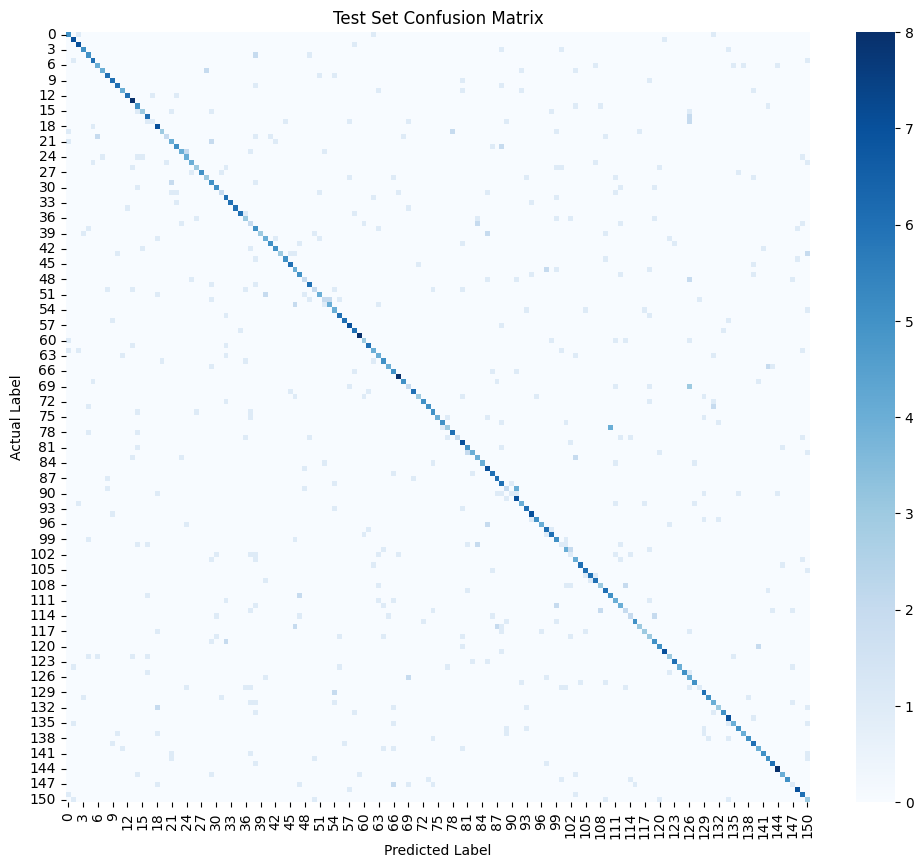

In [9]:
# 3. Confusion Matrix for Test Set
plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(all_labels, all_preds), annot=False, fmt='d', cmap='Blues')
plt.title("Test Set Confusion Matrix")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.show()

# Run with cleaned images (10 aug)

In [ ]:
# 1. Load the .npy files
# x_train_10aug = np.load('./Pokemon/X_train_10aug.npy')
# y_train_10aug = np.load('./Pokemon/y_train_10aug.npy')

# x_val_10aug = np.load('./Pokemon/X_val_10aug.npy')
# y_val_10aug = np.load('./Pokemon/y_val_10aug.npy')

# x_test_10aug = np.load('./Pokemon/X_test_10aug.npy')
# y_test_10aug = np.load('./Pokemon/y_test_10aug.npy')

# Google Drive path
x_train_10aug = np.load(DATA_DIR / "X_train_10aug.npy")
y_train_10aug = np.load(DATA_DIR / "y_train_10aug.npy")

x_val_10aug = np.load(DATA_DIR / "X_val_10aug.npy")
y_val_10aug = np.load(DATA_DIR / "y_val_10aug.npy")

x_test_10aug = np.load(DATA_DIR / "X_test_10aug.npy")
y_test_10aug = np.load(DATA_DIR / "y_test_10aug.npy")


le = LabelEncoder()
y_train_idx_10aug = le.fit_transform(y_train_10aug)  
y_val_idx_10aug   = le.transform(y_val_10aug)        
y_test_idx_10aug  = le.transform(y_test_10aug)

# Save the class names for later plotting
class_names = le.classes_
print(f"Detected {len(class_names)} classes: {class_names}")

Detected 151 classes: ['abra' 'aerodactyl' 'alakazam' 'arbok' 'arcanine' 'articuno' 'beedrill'
 'bellsprout' 'blastoise' 'bulbasaur' 'butterfree' 'caterpie' 'chansey'
 'charizard' 'charmander' 'charmeleon' 'clefable' 'clefairy' 'cloyster'
 'cubone' 'dewgong' 'diglett' 'ditto' 'dodrio' 'doduo' 'dragonair'
 'dragonite' 'dratini' 'drowzee' 'dugtrio' 'eevee' 'ekans' 'electabuzz'
 'electrode' 'exeggcute' 'exeggutor' "farfetch'd" 'fearow' 'flareon'
 'gastly' 'gengar' 'geodude' 'gloom' 'golbat' 'goldeen' 'golduck' 'golem'
 'graveler' 'grimer' 'growlithe' 'gyarados' 'haunter' 'hitmonchan'
 'hitmonlee' 'horsea' 'hypno' 'ivysaur' 'jigglypuff' 'jolteon' 'jynx'
 'kabuto' 'kabutops' 'kadabra' 'kakuna' 'kangaskhan' 'kingler' 'koffing'
 'krabby' 'lapras' 'lickitung' 'machamp' 'machoke' 'machop' 'magikarp'
 'magmar' 'magnemite' 'magneton' 'mankey' 'marowak' 'meowth' 'metapod'
 'mew' 'mewtwo' 'moltres' 'mr mime' 'muk' 'nidoking' 'nidoqueen'
 'nidoran♀' 'nidoran♂' 'nidorina' 'nidorino' 'ninetales' 'oddi

In [11]:
train_loader_10aug = DataLoader(NumpyDataset(x_train_10aug, y_train_idx_10aug, transform=train_transform), 
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader_10aug   = DataLoader(NumpyDataset(x_val_10aug, y_val_idx_10aug, transform=val_transform), 
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader_10aug  = DataLoader(NumpyDataset(x_test_10aug, y_test_idx_10aug, transform=val_transform), 
                          batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# Initialize Model
model_10aug = CNN(num_classes=len(le.classes_)).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model_10aug.parameters(), lr=1e-4, weight_decay=0.01)

# Dictionary to store history for plotting
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    model_10aug.train()
    train_loss, train_correct = 0, 0
    
    for images, labels in train_loader_10aug:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model_10aug(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
    
    # Validation
    model_10aug.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader_10aug:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model_10aug(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            
    # Calculate averages
    metrics = {
        "train_loss": train_loss / len(x_train_10aug),
        "train_acc":  train_correct / len(x_train_10aug),
        "val_loss":   val_loss / len(x_val_10aug),
        "val_acc":    val_correct / len(x_val_10aug)
    }
    
    for key in history: history[key].append(metrics[key])
    
    print(f"Epoch {epoch:02d}/{EPOCHS} | Train Loss: {metrics['train_loss']:.4f} Acc: {metrics['train_acc']:.4f} | "
          f"Val Loss: {metrics['val_loss']:.4f} Acc: {metrics['val_acc']:.4f}")


# RUNTIME: 117min 25sec

Detected flattened size: 8192
Epoch 01/50 | Train Loss: 4.5077 Acc: 0.0562 | Val Loss: 3.4162 Acc: 0.2525
Epoch 02/50 | Train Loss: 3.6090 Acc: 0.1845 | Val Loss: 2.8134 Acc: 0.3642
Epoch 03/50 | Train Loss: 3.1426 Acc: 0.2727 | Val Loss: 2.4851 Acc: 0.4172
Epoch 04/50 | Train Loss: 2.8177 Acc: 0.3352 | Val Loss: 2.3336 Acc: 0.4429
Epoch 05/50 | Train Loss: 2.5602 Acc: 0.3895 | Val Loss: 2.1997 Acc: 0.4843
Epoch 06/50 | Train Loss: 2.3582 Acc: 0.4304 | Val Loss: 2.0967 Acc: 0.5025
Epoch 07/50 | Train Loss: 2.1851 Acc: 0.4669 | Val Loss: 2.0645 Acc: 0.5182
Epoch 08/50 | Train Loss: 2.0318 Acc: 0.5007 | Val Loss: 2.0075 Acc: 0.5381
Epoch 09/50 | Train Loss: 1.9090 Acc: 0.5290 | Val Loss: 1.9773 Acc: 0.5447
Epoch 10/50 | Train Loss: 1.7923 Acc: 0.5521 | Val Loss: 1.9971 Acc: 0.5588
Epoch 11/50 | Train Loss: 1.6987 Acc: 0.5734 | Val Loss: 1.9085 Acc: 0.5728
Epoch 12/50 | Train Loss: 1.5988 Acc: 0.5964 | Val Loss: 1.9186 Acc: 0.5753
Epoch 13/50 | Train Loss: 1.5225 Acc: 0.6174 | Val Loss: 1

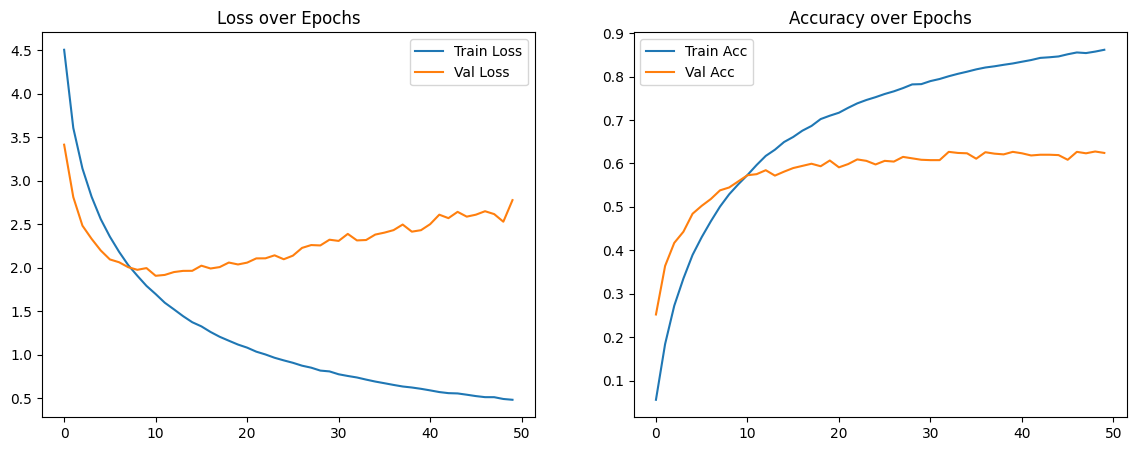

In [17]:
# 1. Plot Training/Validation Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history["train_loss"], label="Train Loss")
ax1.plot(history["val_loss"], label="Val Loss")
ax1.set_title("Loss over Epochs")
ax1.legend()

ax2.plot(history["train_acc"], label="Train Acc")
ax2.plot(history["val_acc"], label="Val Acc")
ax2.set_title("Accuracy over Epochs")
ax2.legend()

plt.show()

In [29]:
# 2. Final Evaluation on Test Set
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import torch.nn.functional as F

model_10aug.eval()
all_preds = []
all_labels = []
all_probs = [] # Needed for ROC-AUC

with torch.no_grad():
    for images, labels in test_loader_10aug:
        images = images.to(DEVICE)
        outputs = model_10aug(images)
        
        # Get probabilities using Softmax
        probs = F.softmax(outputs, dim=1)
        
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

# 1. Precision, Recall, and F1-score
# These are all included in the classification_report
print("--- Detailed Classification Report ---")
# target_names uses the labels from your LabelEncoder
# report = classification_report(all_labels, all_preds, target_names=le.classes_, output_dict=True, zero_division=0)
# print(report)

print(classification_report(all_labels, all_preds, target_names=le.classes_, zero_division=0))

report = classification_report(
    all_labels,
    all_preds,
    target_names=le.classes_,
    output_dict=True,
    zero_division=0
)


# 2. ROC-AUC Score
# For multi-class, we must specify multi_class='ovr' (One-vs-Rest)
# and 'macro' or 'weighted' averaging.
roc_auc_ovr = roc_auc_score(
    all_labels, 
    all_probs, 
    multi_class='ovr', 
    average='macro'
)

print(f"ROC-AUC Score (One-vs-Rest, Macro): {roc_auc_ovr:.4f}")

y_true_cnn_10aug = np.array(all_labels)
y_pred_cnn_10aug = np.array(all_preds)
roc_auc_cnn_10aug = roc_auc_ovr
val_acc_cnn_10aug = max(history["val_acc"])

# Save report
report_10aug = report

--- Detailed Classification Report ---
              precision    recall  f1-score   support

        abra       0.31      0.62      0.42         8
  aerodactyl       0.50      0.88      0.64         8
    alakazam       0.58      0.88      0.70         8
       arbok       0.33      0.38      0.35         8
    arcanine       0.38      0.38      0.38         8
    articuno       0.64      0.88      0.74         8
    beedrill       0.78      0.88      0.82         8
  bellsprout       1.00      0.62      0.77         8
   blastoise       0.80      0.50      0.62         8
   bulbasaur       0.60      0.75      0.67         8
  butterfree       1.00      0.75      0.86         8
    caterpie       0.44      0.50      0.47         8
     chansey       0.80      0.50      0.62         8
   charizard       0.67      1.00      0.80         8
  charmander       0.45      0.62      0.53         8
  charmeleon       0.50      0.62      0.56         8
    clefable       1.00      0.62      0.7

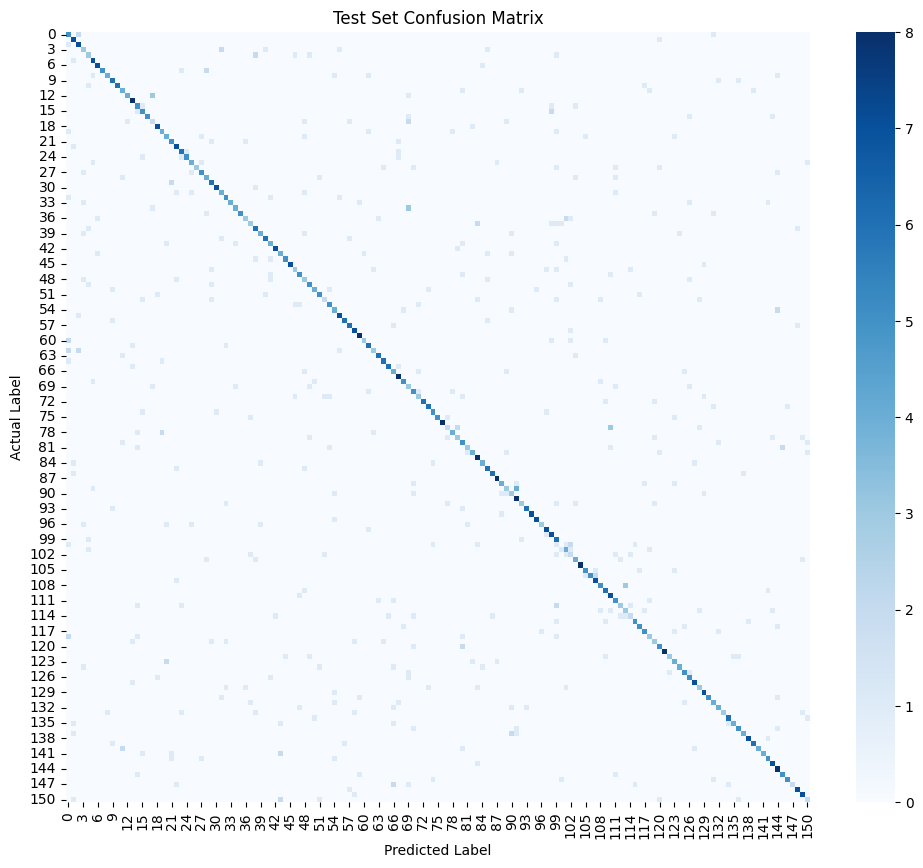

In [19]:
# 3. Confusion Matrix for Test Set
plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(all_labels, all_preds), annot=False, fmt='d', cmap='Blues')
plt.title("Test Set Confusion Matrix")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.show()

In [ ]:
cnn_results_df = pd.DataFrame([
    {
        "Model": "CNN",
        "Dataset": "5aug",
        "Accuracy": report_5aug["accuracy"],
        "Macro Precision": report_5aug["macro avg"]["precision"],
        "Macro Recall": report_5aug["macro avg"]["recall"],
        "Macro F1": report_5aug["macro avg"]["f1-score"],
        "Weighted F1": report_5aug["weighted avg"]["f1-score"],
        "Validation Accuracy": val_acc_cnn_5aug,   # must be a single number
        "ROC-AUC": roc_auc_cnn_5aug
    },
    {
        "Model": "CNN",
        "Dataset": "10aug",
        "Accuracy": report_10aug["accuracy"],
        "Macro Precision": report_10aug["macro avg"]["precision"],
        "Macro Recall": report_10aug["macro avg"]["recall"],
        "Macro F1": report_10aug["macro avg"]["f1-score"],
        "Weighted F1": report_10aug["weighted avg"]["f1-score"],
        "Validation Accuracy": val_acc_cnn_10aug,  # must be a single number
        "ROC-AUC": roc_auc_cnn_10aug
    }
])

cnn_results_df

cnn_results_df = pd.read_csv("cnn_metrics.csv")

,Model,Dataset,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Validation Accuracy,ROC-AUC
0,CNN,5aug,0.579470,0.619171,0.579470,0.577126,0.577126,0.627483,0.972197
1,CNN,10aug,0.619205,0.649536,0.619205,0.615573,0.615573,0.627483,0.974752
